# Iris data 시각화 및 학습 예제

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt


In [3]:
# UCI 데이터베이스에서 붓꽃 데이터셋을 가져온다
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data",
                names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class'])
#sepal_length : 꽃받침 길이
#sepal_width : 꽃받침 폭
#petal_length : 꽃잎 길이
#petal_width : 꽃잎 폭
#class : 분류하고자 하는 class (3개, vesicolor/virginica/setosa)

# 데이터 유형을 살펴본다
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
#데이터프레임의 정보를 요약한다
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# 1~10번 데이터를 확인한다
df.head(15)

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


Dataframe의 조건문 설정

In [7]:
# sepal_length가 5.0보다 큰 로우만 선택한다
df2 = df.loc[df['sepal_length'] > 5]
df2 = df.loc[df['sepal_width'] > 3]
print(df2)

     sepal_length  sepal_width  petal_length  petal_width           class
0             5.1          3.5           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
5             5.4          3.9           1.7          0.4     Iris-setosa
..            ...          ...           ...          ...             ...
140           6.7          3.1           5.6          2.4  Iris-virginica
141           6.9          3.1           5.1          2.3  Iris-virginica
143           6.8          3.2           5.9          2.3  Iris-virginica
144           6.7          3.3           5.7          2.5  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica

[67 rows x 5 columns]


Unique한 class 확인

In [8]:
df['class'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

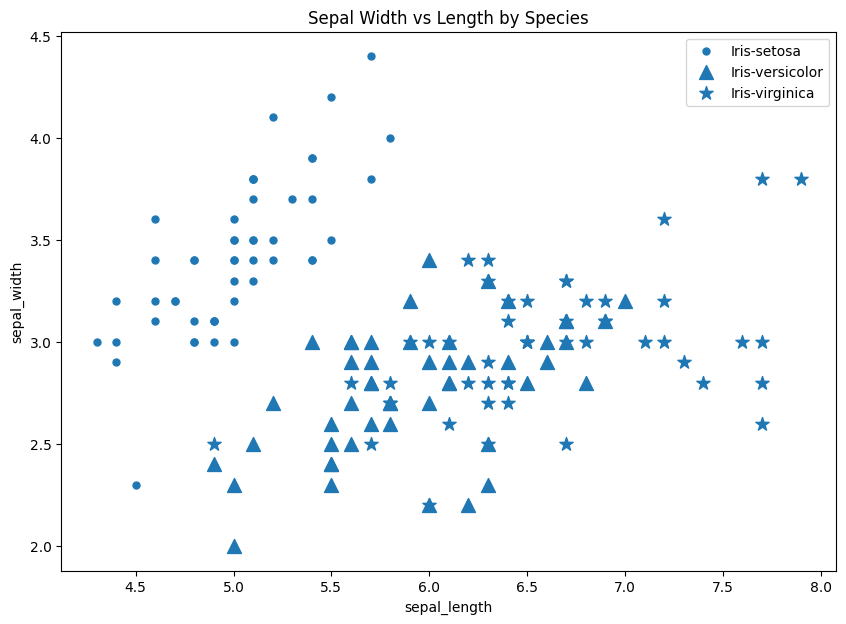

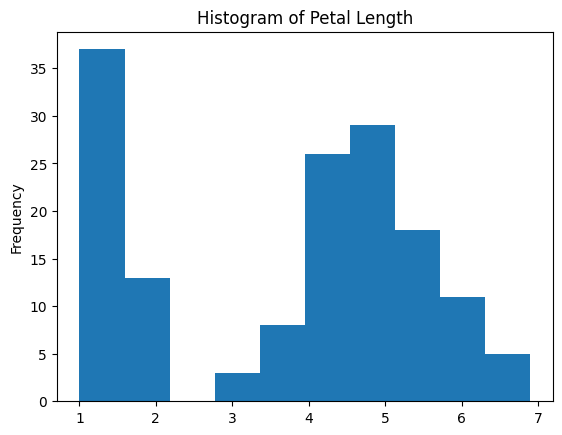

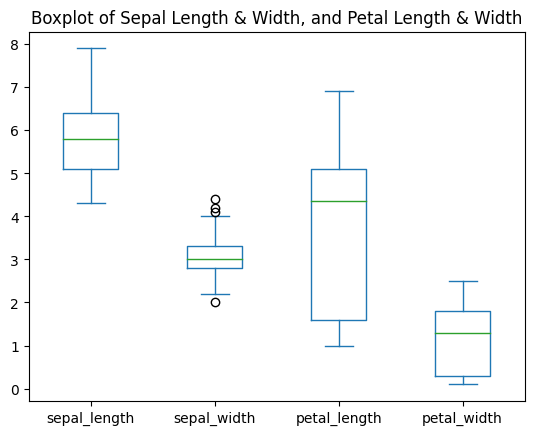

In [9]:
'''
판다스를 활용한 데이터 시각화
'''

# 클래스별로 마커 모양을 지정한다
marker_shapes = ['.', '^', '*']

# 점차트를 그린다
for i, species in enumerate(df['class'].unique()):
  if i == 0:
    ax = df[df['class'] == species].plot.scatter(x='sepal_length', y='sepal_width',
                                                 marker=marker_shapes[i], s=100,title="Sepal Width vs Length by Species",
                                                 label=species, figsize=(10,7))
  else:
    df[df['class'] == species].plot.scatter(x='sepal_length', y='sepal_width', marker=marker_shapes[i],
                                            s=100, title="Sepal Width vs Length by Species", label=species, ax=ax)
plt.show()

# 히스토그램을 그린다
df['petal_length'].plot.hist(title='Histogram of Petal Length')
plt.show()

# 상자차트를 그린다
df.plot.box(title='Boxplot of Sepal Length & Width, and Petal Length & Width')
plt.show()

학습을 위한 데이터셋 구성

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 학습 데이터와 label을 분류
X = df.iloc[:,0:4].values
y = df.iloc[:,4].values

encoder =  LabelEncoder()
y1 = encoder.fit_transform(y)
print(y1)
Y = pd.get_dummies(y1).values #one-hot encoding
print(Y)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y,
                                                    test_size=0.2,
                                                    random_state=1)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120, 3), (30, 3))

모델 구성

In [12]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

model = Sequential()
model.add(Dense(64,input_shape=(4,),activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(3,activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                320       
                                                                 
 dense_1 (Dense)             (None, 64)                4160      
                                                                 
 dense_2 (Dense)             (None, 3)                 195       
                                                                 
Total params: 4675 (18.26 KB)
Trainable params: 4675 (18.26 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Compile & Training

In [13]:
model.compile(loss='categorical_crossentropy',
              optimizer='Adam',
              metrics=['acc'])
hist = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, verbose=1)

Epoch 1/100
4/4 [==============================] - 2s 335ms/step - loss: 1.0917 - acc: 0.3667 - val_loss: 1.0751 - val_acc: 0.2000
Epoch 2/100
4/4 [==============================] - 0s 31ms/step - loss: 0.9644 - acc: 0.3667 - val_loss: 0.9707 - val_acc: 0.2000
Epoch 3/100
4/4 [==============================] - 0s 45ms/step - loss: 0.8703 - acc: 0.4750 - val_loss: 0.8718 - val_acc: 0.5667
Epoch 4/100
4/4 [==============================] - 0s 45ms/step - loss: 0.7881 - acc: 0.6917 - val_loss: 0.7975 - val_acc: 0.6000
Epoch 5/100
4/4 [==============================] - 0s 45ms/step - loss: 0.7124 - acc: 0.7000 - val_loss: 0.7327 - val_acc: 0.6000
Epoch 6/100
4/4 [==============================] - 0s 50ms/step - loss: 0.6477 - acc: 0.7500 - val_loss: 0.6722 - val_acc: 0.6333
Epoch 7/100
4/4 [==============================] - 0s 30ms/step - loss: 0.5955 - acc: 0.7833 - val_loss: 0.6249 - val_acc: 0.7000
Epoch 8/100
4/4 [==============================] - 0s 40ms/step - loss: 0.5509 - acc: 0.8

Test 결과 확인 및 학습과정 시각화

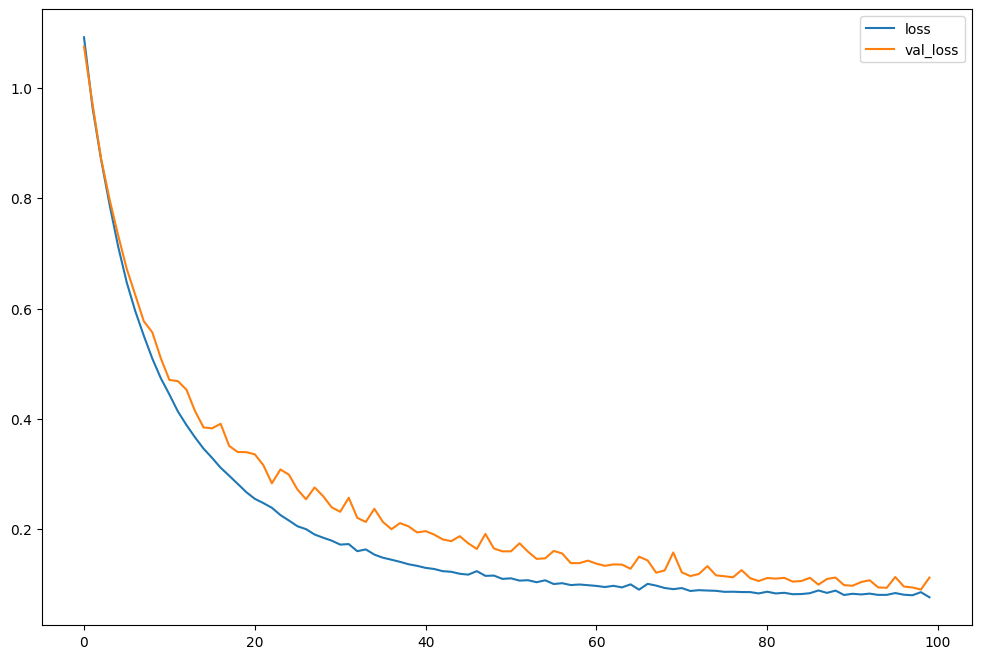

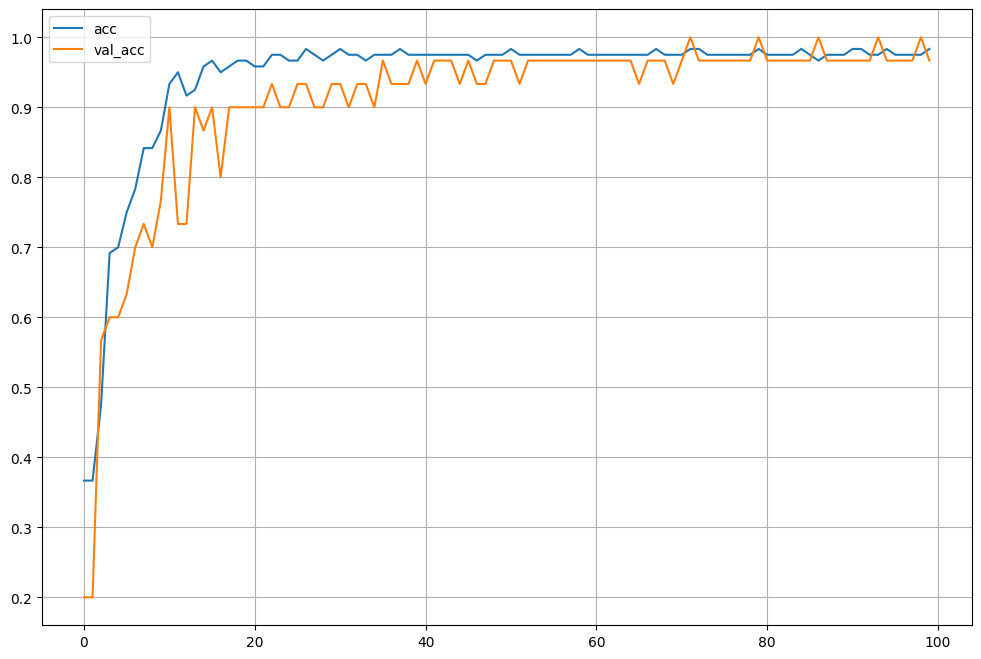

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.legend(['loss','val_loss'])
plt.show()

plt.figure(figsize=(12,8))
plt.plot(hist.history['acc'])
plt.plot(hist.history['val_acc'])
plt.legend(['acc','val_acc'])
plt.grid()
plt.show()

Test 정확도 확인

In [15]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy = {:.2f}".format(accuracy))

1/1 [==============================] - 0s 25ms/step - loss: 0.1123 - acc: 0.9667
Accuracy = 0.97


#타이타닉 생존자 데이터 시각화

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn의 내장 데이터셋인 Titanic 데이터 로드
titanic = sns.load_dataset('titanic')



In [17]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


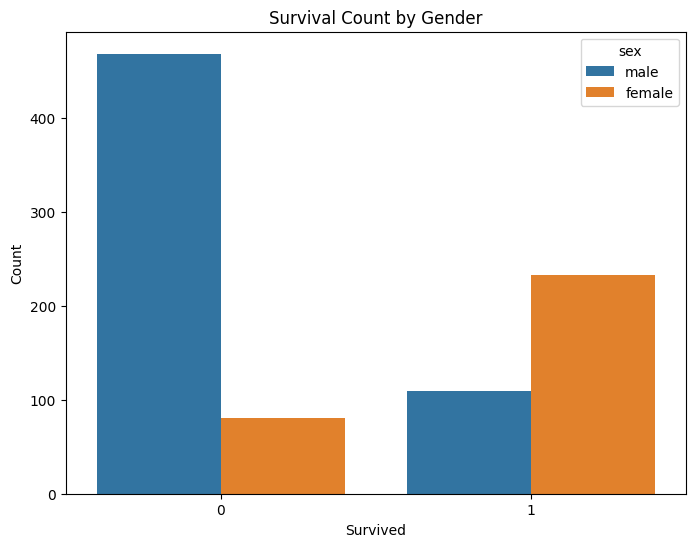

In [18]:
# Countplot: 성별에 따른 생존자 및 사망자 수 시각화
plt.figure(figsize=(8, 6))
sns.countplot(x='survived', hue='sex', data=titanic)
plt.title('Survival Count by Gender')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

<ipython-input-19-a8ef6ee5dbd6>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='class', y='age', data=titanic, ci=None)


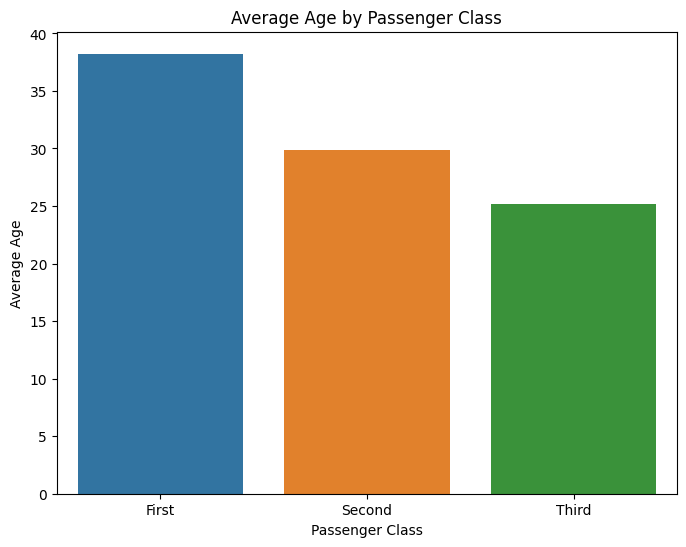

In [19]:
# Barplot: 객실 등급에 따른 평균 나이 시각화
plt.figure(figsize=(8, 6))
sns.barplot(x='class', y='age', data=titanic, ci=None)
plt.title('Average Age by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Average Age')
plt.show()


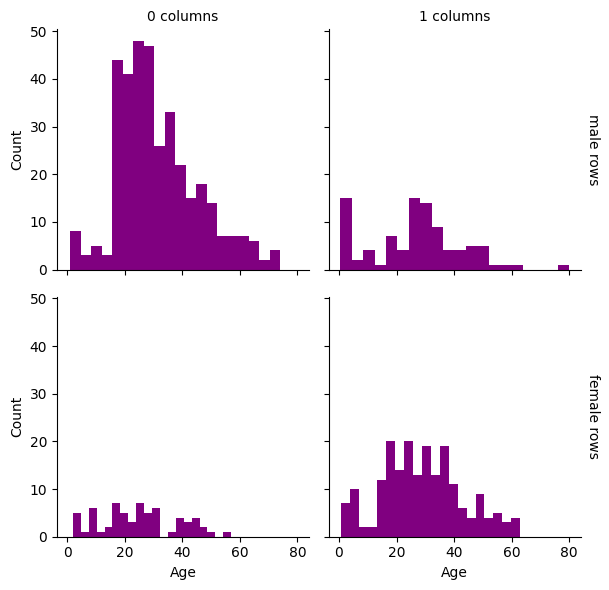

In [20]:
# FacetGrid: 객실 등급 및 성별에 따른 생존 여부 시각화
g = sns.FacetGrid(titanic, col='survived', row='sex', margin_titles=True, height=3)
g.map(plt.hist, 'age', bins=20, color='purple')
g.set_axis_labels('Age', 'Count')
g.set_titles(col_template='{col_name} columns', row_template='{row_name} rows')
plt.show()

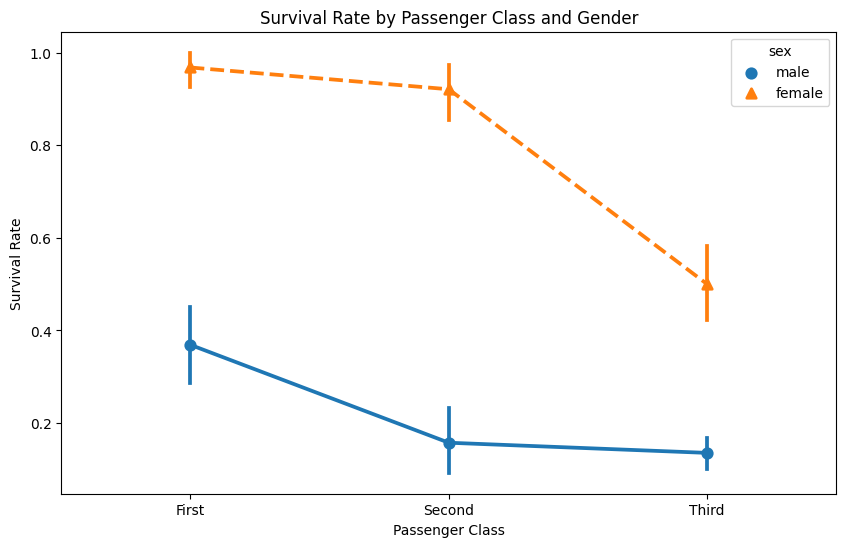

In [21]:
# Pointplot: 객실 등급, 성별에 따른 생존률 시각화
plt.figure(figsize=(10, 6))
sns.pointplot(x='class', y='survived', hue='sex', data=titanic, markers=['o', '^'], linestyles=['-', '--'])
plt.title('Survival Rate by Passenger Class and Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()